In [1]:
import uproot
import numpy as np

## Preparamos los datos

Una vez descargados los archivos .root en nuestro directorio, examinamos su contenido:
- Desde la terminar vemos cuantos objetos tipo tree tiene cada archivo de datos
<center><img src="images/trees.png"></center>
- Para facilitar su uso lo guardamos en variables con nombres significativos

In [2]:
tree_light_data = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")["alazar_data"]
tree_light_parameters = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")["alazar_parameters"]

In [3]:
tree_dark_data = uproot.open("TES1-0.3RN-5GHz-50MHz-extrinsic-2d-trigger-10mV.root")["alazar_data"]
tree_dark_parameters = uproot.open("TES1-0.3RN-5GHz-50MHz-extrinsic-2d-trigger-10mV.root")["alazar_parameters"]

Las keys de tree_light_data representa cada uno de las medidas tomadas por el sensor, 4722 filas, mientras que en tree_light_parameter tenemos los parametros de configuración, solo una fila.

In [4]:
print(tree_light_data.keys())
print(tree_light_parameters.keys())

['samplingFrequency', 'timeStamp', 'startTime', 'DAQ', 'AlpsIOVersion', 'AlazarVersion', 'AlazarApiVersion', 'AlazarDriverVersion', 'cooldown', 'recharge', 'dataChA', 'triggerChA']
['AlpsIOVersion', 'AlazarVersion', 'AlazarApiVersion', 'AlazarDriverVersion', 'DAQ', 'd_or_s', 'cooldown', 'WP1', 'GBWP1', 'WP2', 'GBWP2', 'samplingFrequency', 'adquisition_type', 'adquisition_time', 'type_of_measurement', 'comments', 'number_of_processors', 'thr_1', 'thr_2', 'PreSamples', 'PostSamples', 'filtered_trigger', 'order_1', 'frequency_1', 'order_2', 'frequency_2', 'save_filtered_data']


In [5]:
print(tree_dark_data.keys())
print(tree_dark_parameters.keys())

['samplingFrequency', 'timeStamp', 'startTime', 'DAQ', 'AlpsIOVersion', 'AlazarVersion', 'AlazarApiVersion', 'AlazarDriverVersion', 'cooldown', 'recharge', 'dataChA', 'triggerChA']
['AlpsIOVersion', 'AlazarVersion', 'AlazarApiVersion', 'AlazarDriverVersion', 'DAQ', 'd_or_s', 'cooldown', 'WP1', 'GBWP1', 'WP2', 'GBWP2', 'samplingFrequency', 'adquisition_type', 'adquisition_time', 'type_of_measurement', 'comments', 'number_of_processors', 'thr_1', 'thr_2', 'PreSamples', 'PostSamples', 'filtered_trigger', 'order_1', 'frequency_1', 'order_2', 'frequency_2', 'save_filtered_data']


Verificamos que el Nº de eventos coincide con el del paper.
<center><img src="images/data_description1.png"></center>

In [6]:
print(tree_light_data.num_entries)
print(tree_light_parameters.num_entries)
print(tree_dark_data.num_entries)
print(tree_dark_parameters.num_entries)

4722
1
8872
1


La rama que nos interesa es la de dataChA, aquí es donde se encuentran las muestras de cada pulso.
- Revisamos el primer pulso del laser.
- Estructura TTree tree_light_data
<center><img src="images/structure_tree_light_data.png"></center>


In [11]:
print(tree_light_data["dataChA"])

<TBranchElement 'dataChA' at 0x7f0a227317f0>


In [12]:
primer_pulso = tree_light_data["dataChA"].array(entry_start=0, entry_stop=1, library="np")[0]
print(primer_pulso.shape)
print(type(primer_pulso))
print(primer_pulso)
#Cada uno de esos 1000 valores se corresponden con la Amplitud de la señal que genera el TES al detectar un fotón

(10000,)
<class 'numpy.ndarray'>
[0.0035668  0.00314717 0.00379568 ... 0.00322347 0.00295644 0.00288014]


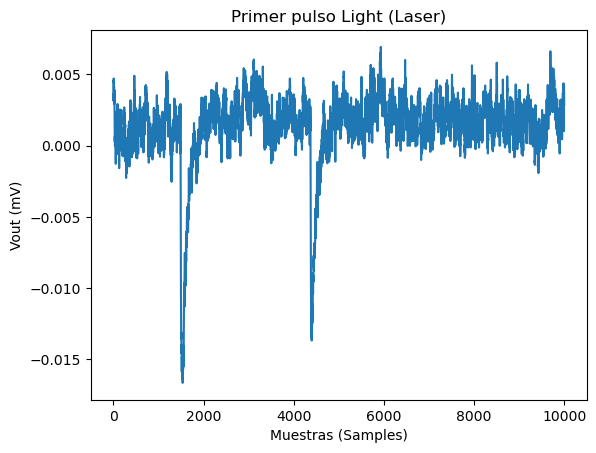

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.plot(primer_pulso)
plt.title("Primer pulso Light (Laser)")
plt.xlabel("Muestras (Samples)")
plt.ylabel("Vout (mV)")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.2)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
plt.show()

In [11]:
primer_pulso_dark = tree_dark_data["dataChA"].array(entry_start=0, entry_stop=1, library="np")[0]
print(primer_pulso_dark.shape)
print(primer_pulso_dark)
#Cada uno de esos 1000 valores se corresponden con la Amplitud de la señal que genera el TES al detectar un evento que no es fotón del laser

(10000,)
[0.00101091 0.00101091 0.00082017 ... 0.00261311 0.0026894  0.00329976]


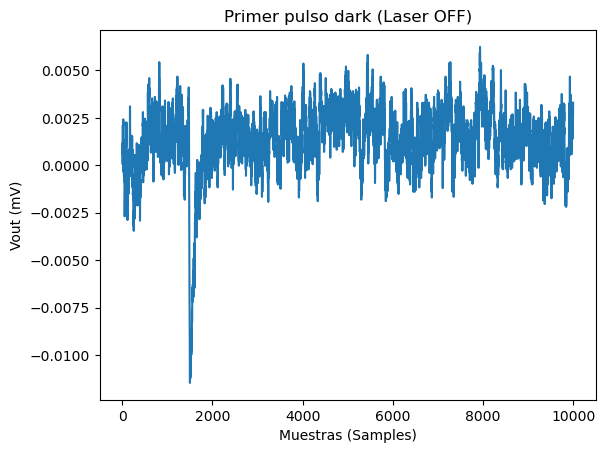

In [ ]:
plt.plot(primer_pulso_dark)
plt.title("Primer pulso dark (Laser OFF)")
plt.xlabel("Muestras (Samples)")
plt.ylabel("Vout (mV)")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.2)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
plt.show()

In [13]:
print(tree_light_data["dataChA"])

<TBranchElement 'dataChA' at 0x7f9970affa40>


Ahora almacenamos todos los eventos (pulsos) de cada dataset (Light y Dark). En el branch ChA están todas las formas de onda de cada pulso.
 

In [7]:
light_pulses = tree_light_data["dataChA"].array(library="np")
dark_pulses = tree_dark_data["dataChA"].array(library="np")

In [8]:
#print(light_signals[0].shape) resultado: (10000,0)
#print(dark_signals[0].shape) resultado: (10000,0)
print(type(light_pulses))
print(light_pulses.shape)
print(light_pulses)
print(light_pulses[0])

<class 'numpy.ndarray'>
(4722,)
[array([0.0035668 , 0.00314717, 0.00379568, ..., 0.00322347, 0.00295644,
        0.00288014], shape=(10000,))
 array([ 5.14991989e-04,  4.76844434e-04,  3.24254215e-04, ...,
        -9.53688869e-05, -1.33516442e-04, -4.38696880e-04], shape=(10000,))
 array([-0.00181201, -0.00165942, -0.00112535, ...,  0.00078202,
         0.0003624 ,  0.00040055], shape=(10000,))               ...
 array([ 6.29434653e-04,  8.96467536e-04,  9.72762646e-04, ...,
         1.90737774e-05, -2.86106661e-04, -1.33516442e-04], shape=(10000,))
 array([0.00097276, 0.00070573, 0.00139239, ..., 0.0019646 , 0.00219348,
        0.00169757], shape=(10000,))
 array([0.00185016, 0.00150683, 0.00181201, ..., 0.0019646 , 0.00265126,
        0.00291829], shape=(10000,))                                    ]
[0.0035668  0.00314717 0.00379568 ... 0.00322347 0.00295644 0.00288014]


### Dibujamos los 3 primeros pulsos de cada grupo para tener una primera idea de su distribución.

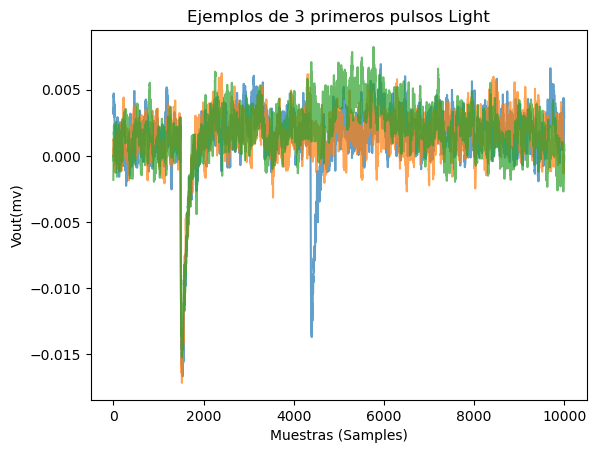

In [ ]:
#Dibujamos 3 pulsos
for i in range(3):
    plt.plot(light_pulses[i], alpha=0.7)

plt.title("Ejemplos de 3 primeros pulsos Light")
plt.xlabel("Muestras (Samples)")
plt.ylabel("Vout(mv)")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.2)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
plt.show()

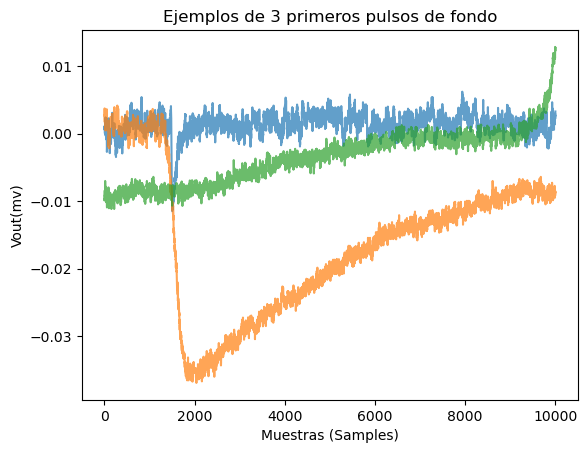

In [ ]:
#También representamos los 3 primeros pulsos Dark
for i in range(3):
    plt.plot(dark_pulses[i], alpha=0.7)

plt.title("Ejemplos de 3 primeros pulsos de fondo")
plt.xlabel("Muestras (Samples)")
plt.ylabel("Vout(mv)")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.2)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
plt.show()

Como primera conclusion podemos decir que los pulsos dark están mucho más dispersos.

### Pulso medio de cada grupo

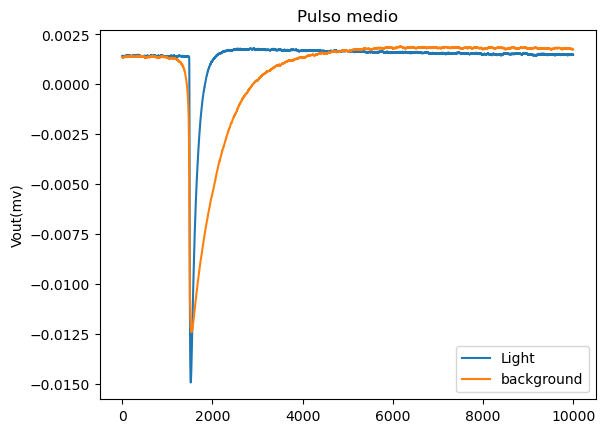

In [16]:
mean_light = np.mean(light_pulses, axis=0)
mean_dark = np.mean(dark_pulses, axis=0)

plt.plot(mean_light, label="Light")
plt.plot(mean_dark, label="background")

plt.legend()
plt.title("Pulso medio")
plt.ylabel("Vout(mv)")
plt.show()

### Distribución de Amplitues
- Obtener la amplitud mínima de cada pulso

In [17]:
light_min_amplts = []
for p in light_pulses:
    muestra_light_min = p.min()
    light_min_amplts.append(muestra_light_min)

dark_min_amplts = []
for k in dark_pulses:
    muestra_dark_min = k.min()
    dark_min_amplts.append(muestra_dark_min)

In [18]:
print(len(light_min_amplts))
print(len(dark_min_amplts))

4722
8872


In [ ]:
plt.hist(light_min_amplts, bins=50, alpha=0.6, label="light")
plt.hist(dark_min_amplts, bins=50, alpha=0.6, label="background", color='gray')

plt.legend()
plt.title("Distribución de amplitudes")
plt.show()